 Today's financial ecosystem encourages understanding trends and patterns in financial behavior in order to improve financial stability and sound decision-making. MAZE applies machine learning techniques to annalyze and predict key financial outcomes including: 
-Financial Stress level
-Savings Goal
=Credit Risk Classification.

By leveraging financial and behavioral features such as monthly income, expenses, debt and spending patterns of the individual, this system aims to provide actionable insights into financial health thus preventing the risk in the increase of financial stress level.

This project emphasizes realistic modelling by addressing data leakage, class imbalance and feature relevance taking into account the correlation between features present. This ensures that the predictions are reliable and aligned with real world financial applications.

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/sylviacoder/Maze-Personal-Finance-Intelligence-Tracker/refs/heads/main/data/raw/personal_finance_tracker_dataset%5B1%5D.csv")

In [12]:
print(df.isnull().sum())
print(df.shape)
print(df.dtypes)

date                      0
user_id                   0
monthly_income            0
monthly_expense_total     0
savings_rate              0
budget_goal               0
financial_scenario        0
credit_score              0
debt_to_income_ratio      0
loan_payment              0
investment_amount         0
subscription_services     0
emergency_fund            0
transaction_count         0
fraud_flag                0
discretionary_spending    0
essential_spending        0
income_type               0
rent_or_mortgage          0
category                  0
cash_flow_status          0
financial_advice_score    0
financial_stress_level    0
actual_savings            0
savings_goal_met          0
dtype: int64
(3000, 25)
date                       object
user_id                     int64
monthly_income            float64
monthly_expense_total     float64
savings_rate              float64
budget_goal               float64
financial_scenario         object
credit_score              float64
debt

There are no missing values in any of the features. Two of the three targets for the projects happen to be object.

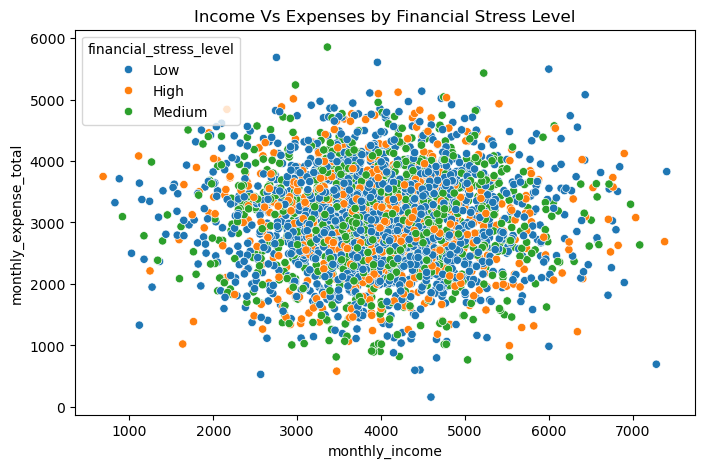

In [15]:
# Expenses vs Income
plt.figure(figsize=(8,5))
sns.scatterplot(x="monthly_income", y="monthly_expense_total",hue="financial_stress_level",  data=df)
plt.title("Income Vs Expenses by Financial Stress Level")
plt.show()

The scatter plot visualization tells no story. The goal of the visualization was to show the monthly income against monthly expenses filtered by financial stress level. Normal case scenario ought to be if the expense is more than the monthly income, then the financial stress of the individual should be high(orange). And if the monthly income is higher than the monthly expenses above an average medium ratio, the financial stress of the individual should be low(blue). But in the above visualization, all seem to be clustered with no story to tell. Ordinarily, the blue dots that symbolizes low stress level should be clustered lower and orange, higher while green maintains midpoints

In [18]:
df.head(2)

,date,user_id,monthly_income,monthly_expense_total,savings_rate,budget_goal,financial_scenario,credit_score,debt_to_income_ratio,loan_payment,...,discretionary_spending,essential_spending,income_type,rent_or_mortgage,category,cash_flow_status,financial_advice_score,financial_stress_level,actual_savings,savings_goal_met
0,2019-01-01,1584,3119.58,3212.07,0.38,3676.11,inflation,721.0,0.56,125.77,...,857.55,1910.85,Freelance,1501.65,Investments,Positive,8.3,Low,0.0,0
1,2019-01-31,1045,3262.44,3732.81,0.10,2607.17,inflation,670.0,0.42,454.19,...,534.51,3165.20,Salary,1603.17,Investments,Positive,22.6,Low,0.0,0


The problem with the visualization originated from the dataset itself. If you look closely at the table above, the first row's monthly income is 3119.58 and the monthly expense is 3212.07. Logically this should mean that the individual spends more than his or her monthly income with nothing to set aside as savings. This anomaly ought to be registered as High for the said individual's financial stress level but instead it is registered as low in the dataset, the same goes for the second row. To rectify this, there is a need for heuristic rule generting the stress level from features in order to create a multiclass label for low, medium and high.

In [23]:
def calculate_stress_label(row):
    score = 0
    if row['debt_to_income_ratio'] > 0.45: score += 4
    elif row['debt_to_income_ratio'] > 0.30: score += 2
    
    if row['savings_rate'] < 0.05: score += 3
    elif row['savings_rate'] < 0.15: score += 1
    
    budget_usage = row['monthly_expense_total'] / (row['budget_goal'] + 1)
    if budget_usage > 1.1: score += 3
    elif budget_usage > 0.9: score += 1
    
    coverage = row['emergency_fund'] / (row['monthly_expense_total'] + 1)
    if coverage < 1: score += 3
    elif coverage < 3: score += 1

    if score >= 8: return 'High'
    elif score >= 4: return 'Medium'
    else: return 'Low'

df['financial_stress_level'] = df.apply(calculate_stress_label, axis=1)


#### Financial Stress Label Feature Engineering

This code performs feature engineering by creating a new variable, financial_stress_level, using a rule-based scoring system. It evaluates each individual across four financial indicators: debt-to-income ratio, savings rate, budget usage, and emergency fund coverage.
Each condition contributes weighted points to a cumulative stress score, where riskier financial behaviors (e.g., high debt, low savings, overspending, low emergency funds) add more points. Small constants are added in divisions to prevent errors like division by zero.
Finally, the function is applied row-wise to the dataset to generate the new feature. This engineered label simplifies multiple financial metrics into a single interpretable category, making it useful for analysis or as a target variable in machine learning models.

In [35]:
df.head(2)

,date,user_id,monthly_income,monthly_expense_total,savings_rate,budget_goal,financial_scenario,credit_score,debt_to_income_ratio,loan_payment,...,discretionary_spending,essential_spending,income_type,rent_or_mortgage,category,cash_flow_status,financial_advice_score,financial_stress_level,actual_savings,savings_goal_met
0,2019-01-01,1584,3119.58,3212.07,0.38,3676.11,inflation,721.0,0.56,125.77,...,857.55,1910.85,Freelance,1501.65,Investments,Positive,8.3,Medium,0.0,0
1,2019-01-31,1045,3262.44,3732.81,0.10,2607.17,inflation,670.0,0.42,454.19,...,534.51,3165.20,Salary,1603.17,Investments,Positive,22.6,High,0.0,0


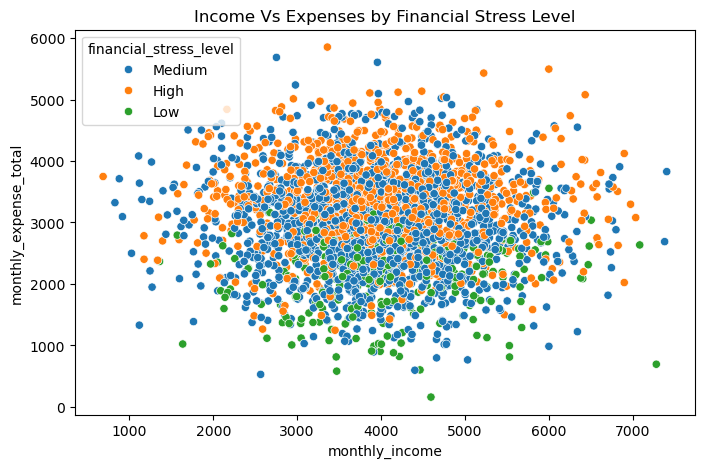

In [41]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="monthly_income", y="monthly_expense_total",hue="financial_stress_level",  data=df)
plt.title("Income Vs Expenses by Financial Stress Level")
plt.show()

Observation: Now the scatter plot tells a story. The datapoints with low financial stress level(green) are settled down, the high risk are clustered up and the medium are mostly seen in the middle.
There is another story to tell here, the medium points seem to be much more in number than any of the other classes which may signify class imbalance, which could be a problem when modelling

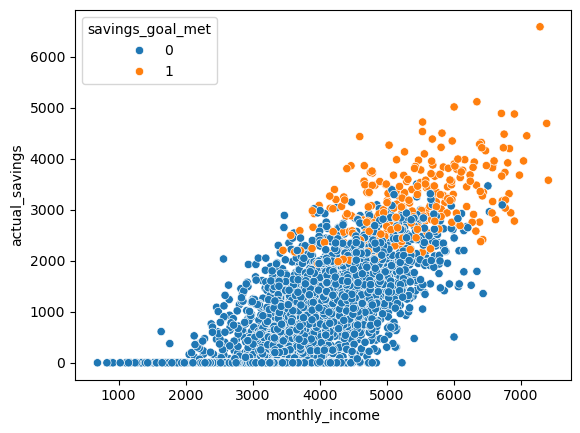

In [56]:
sns.scatterplot(x='monthly_income', y='actual_savings', hue='savings_goal_met', data=df)
plt.show()

MAZE's goal is not only to determine the financial stress level of an individual but also to ascertain if an individual reached his or her savings goal. The above illustration shows the interaction between monthly income and actual savings, filtering datapoints accoring to the savings goal met.

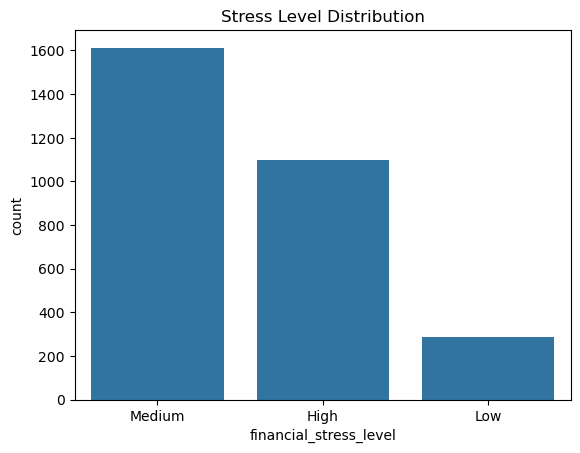

In [49]:
sns.countplot(x='financial_stress_level', data=df)
plt.title("Stress Level Distribution")
plt.show()

Potential risk of class imbalance. If not rectified, this could make the machine model favor medium claasses prediction much more than other classes

In [52]:
num_col = df.select_dtypes(include=['number'])

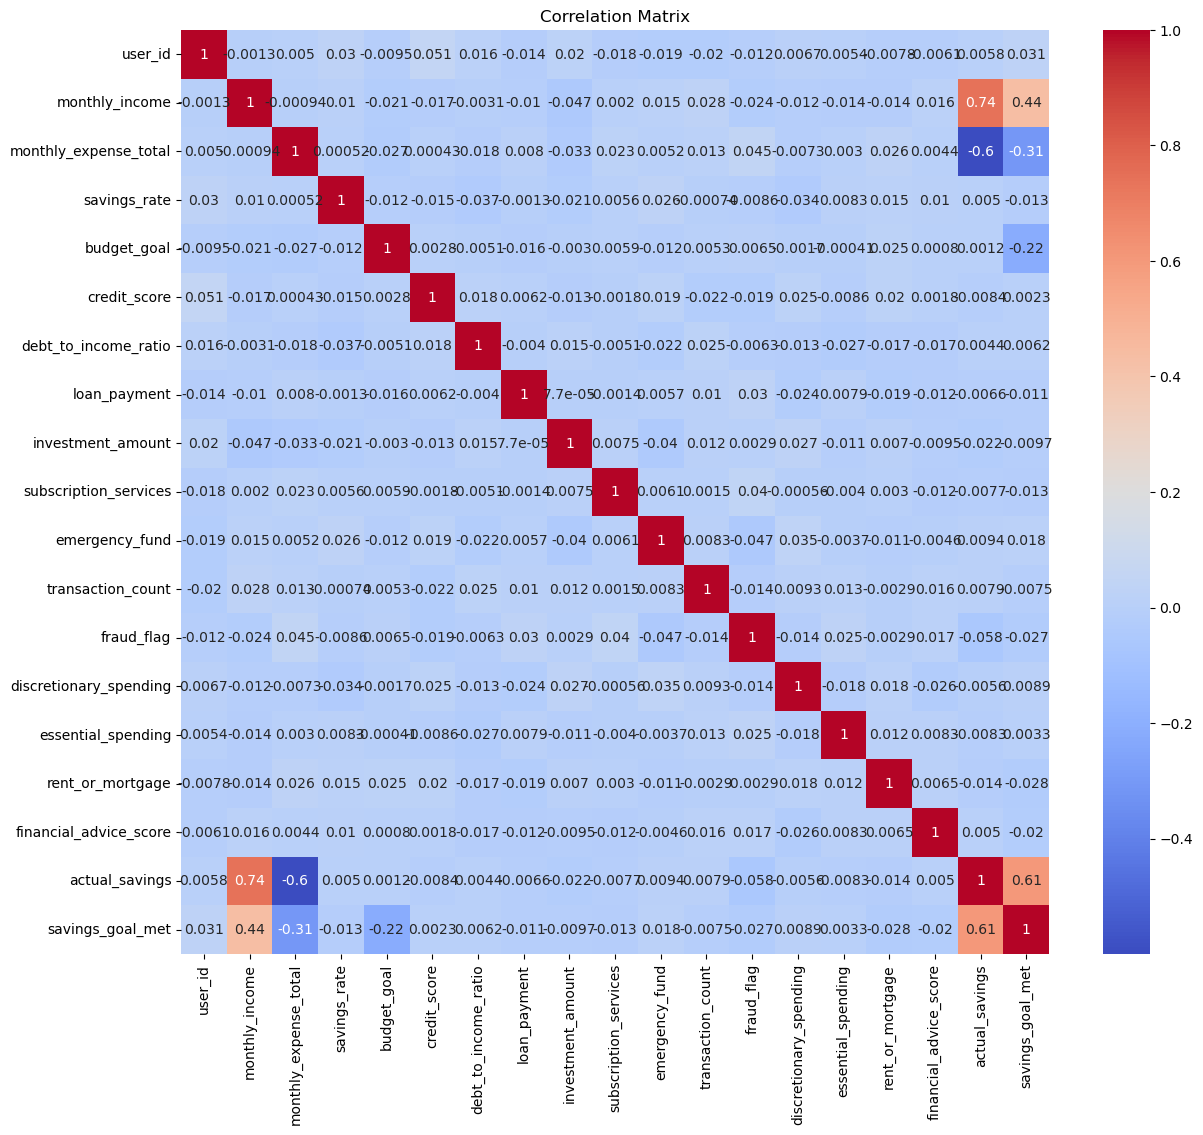

In [59]:
plt.figure(figsize=(14,12))
corr = num_col.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

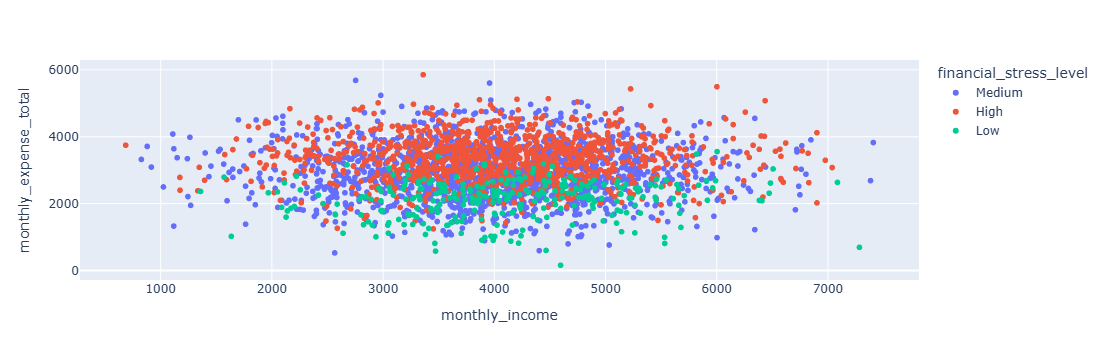

In [61]:
fig = px.scatter(df,x='monthly_income',y='monthly_expense_total',color='financial_stress_level',hover_data=['credit_score', 'savings_rate'],template='plotly')
fig.show()

The plotly visualization transforms our raw data to a visual interactive story, revealing how income and spending patterns quietly shape financial stress, with hidden insights emerging on every hover.

In [74]:
df['credit_risk'] = pd.cut(df['credit_score'],bins=[300, 580, 670, 740, 850],
    labels=['Poor', 'Fair', 'Good', 'Excellent']
)

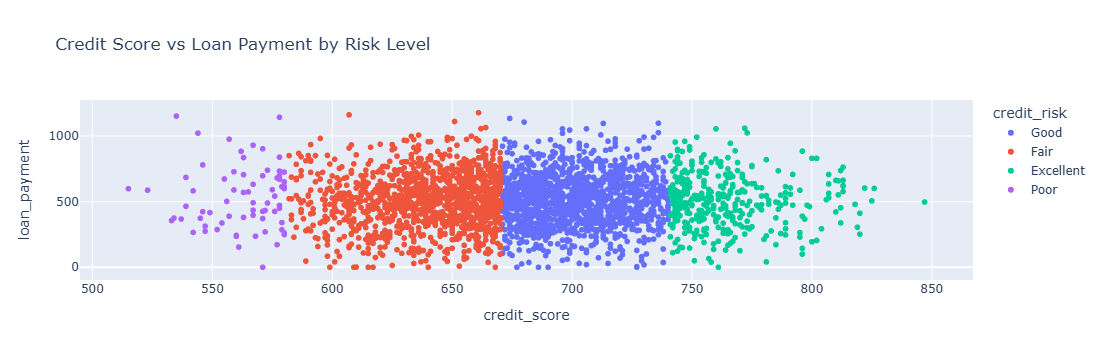

In [76]:
fig = px.scatter(df,x='credit_score',y='loan_payment',color='credit_risk',title='Credit Score vs Loan Payment by Risk Level',hover_data=['monthly_income']
)
fig.show()

Visualizes the relationship between credit score and loan payments, with points colored by credit risk level and additional income details shown on hover to reveal patterns in borrowing behavior.

In [66]:
pl_col = ['monthly_income','monthly_expense_total','savings_rate','credit_score','debt_to_income_ratio']

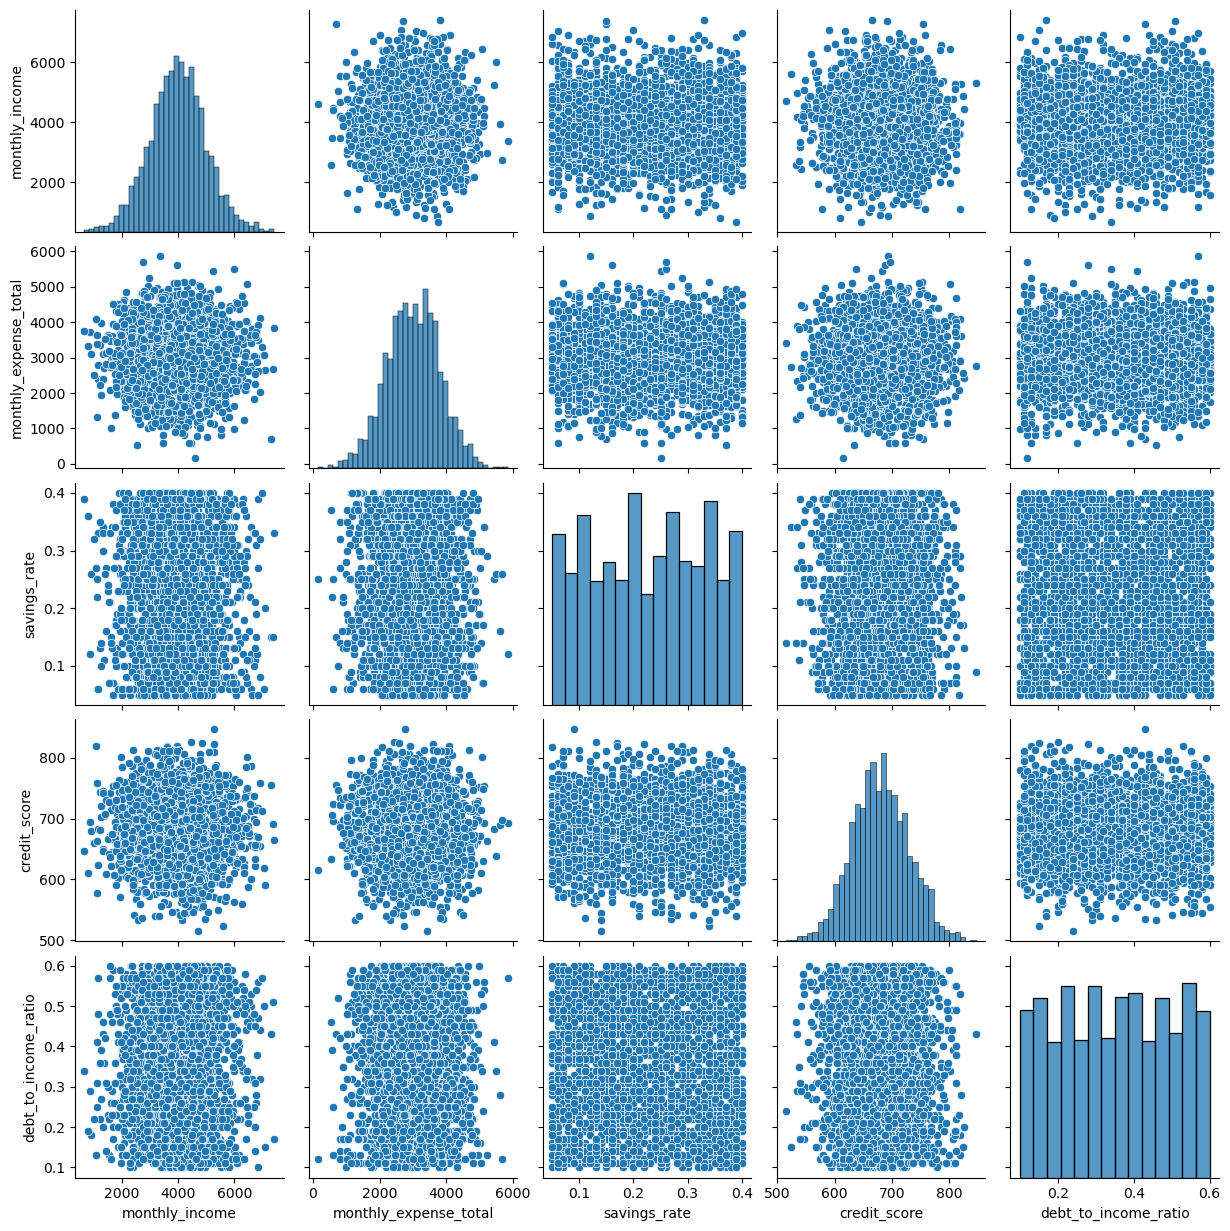

In [68]:
sns.pairplot(df[pl_col])
plt.show()

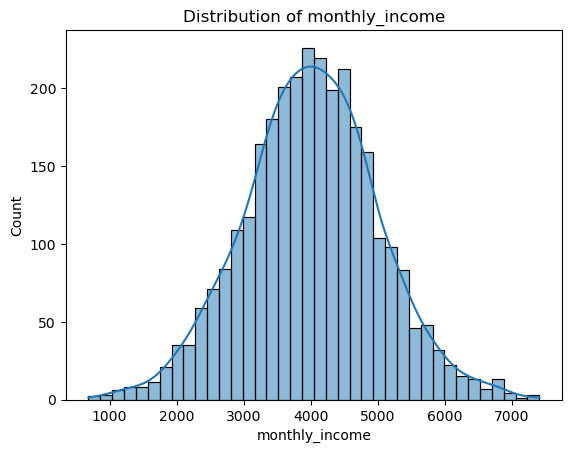

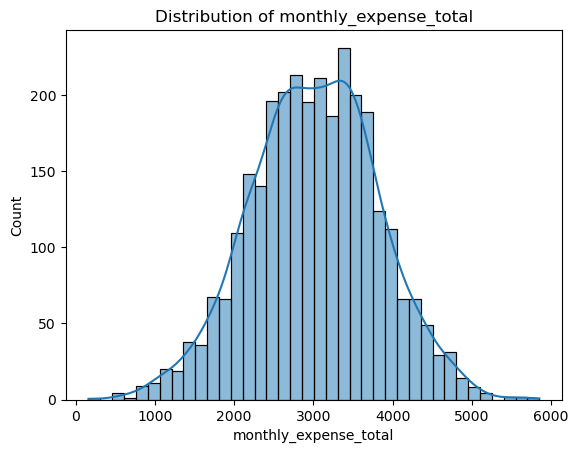

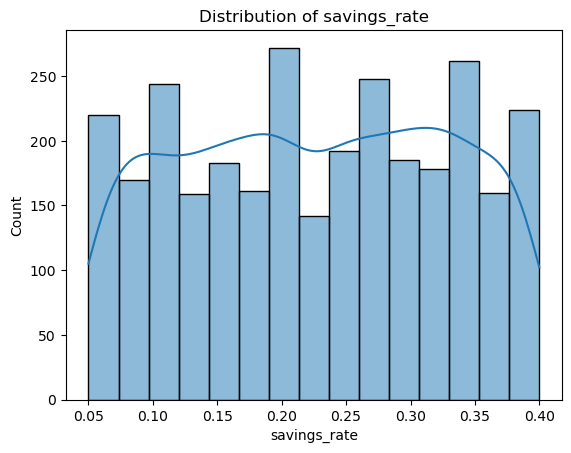

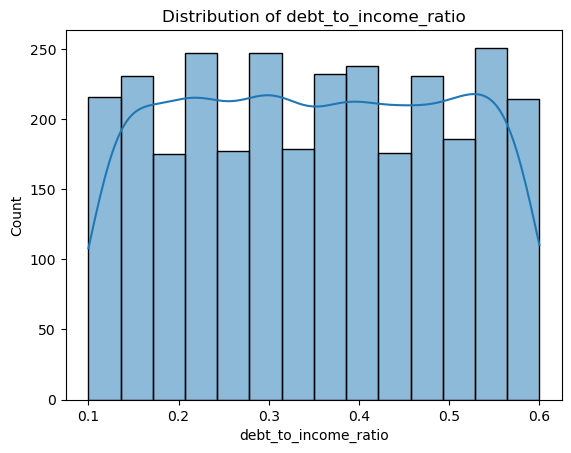

In [70]:
features = ['monthly_income','monthly_expense_total','savings_rate','debt_to_income_ratio']
for col in features:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

Observation: 
The project highlights key patterns in financial health: spending and low savings increase financial stress, while higher credit scores correspond to lower loan risk. Engineered features like financial stress labels effectively summarize multiple metrics, revealing how income, expenses, credit, and savings interact to shape overall financial well-being.